In [ ]:
#@title imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import cv2
import networkx as nx
from networkx.algorithms.isomorphism import GraphMatcher
from collections import defaultdict
import random
import copy
import itertools
import os
import shutil
import pickle
from google.colab import drive
import json

!pip install torch torch_geometric networkx
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, SAGEConv, GatedGraphConv, BatchNorm, ChebConv, GATConv, global_add_pool, MessagePassing, GINConv
from torch_geometric.utils import from_networkx

from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
import torchvision
import torch.nn.functional as F
from torch.nn import BatchNorm1d
from torch.utils.data.dataset import random_split
from torch.utils.data.dataloader import default_collate
import torch_geometric.nn as pyg_nn
#DGIConv
#GAPConv, EGConv, GraphUNetEncoder, GraphUNetDecoder, DCNNConv, GWNNConv

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
drive.mount('/content/drive')
results = [] #ovo treba svaki put runat
#resultsJson = [] #ovo nikad
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Top 10 results for GCN:

      lr       b      d      activation   loss       optimizer   accuracy
 1.   0.001    64     6      ReLU         MSELoss    SGD          0.7143
 2.   0.0001   4      2      ReLU         BCELoss    Adam         0.7143
 3.   0.01     16     6      LeakyReLU    BCELoss    SGD          0.7000
 4.   0.1      4      6      ReLU         MSELoss    Adam         0.6786
 5.   0.1      16     2      ReLU         BCELoss    Adam         0.6786
 6.   0.01     4      4      ReLU         MSELoss    SGD          0.6786
 7.   0.01     4      6      ReLU         MSELoss    Adam         0.6786
 8.   0.01     64     4      ReLU         MSELoss    Adam         0.6786
 9.   0.0001   16     6      ReLU         MSELoss    Adam         0.6786
 10.  0.0001   64     6      ReLU         MSELoss    Adam         0.6786
 11.  0.01     16     4      LeakyReLU    BCELoss    SGD          0.6750
 12.  0.1      16     4      Tanh         BCELoss    SGD          0.6750
 13.  0.01     64     2  

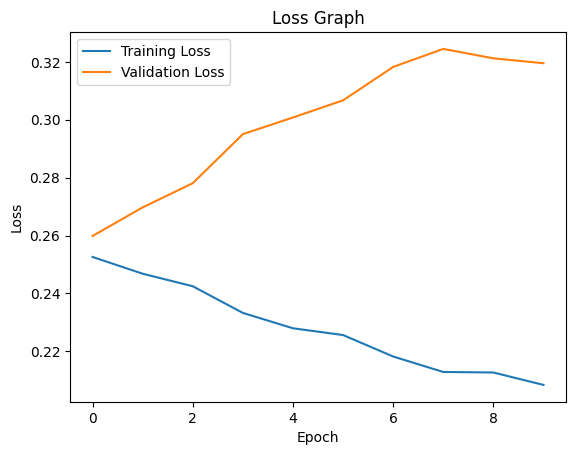

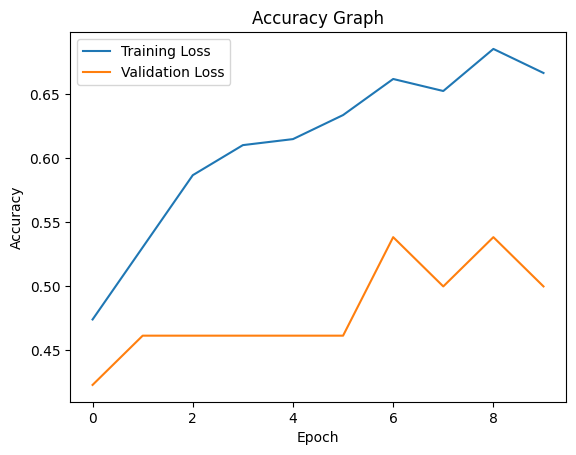


 2.   0.1      16     4      ReLU         BCELoss    Adam         0.7857     SGConv

False Positive Rate: 0.0000
False Negative Rate: 0.2143



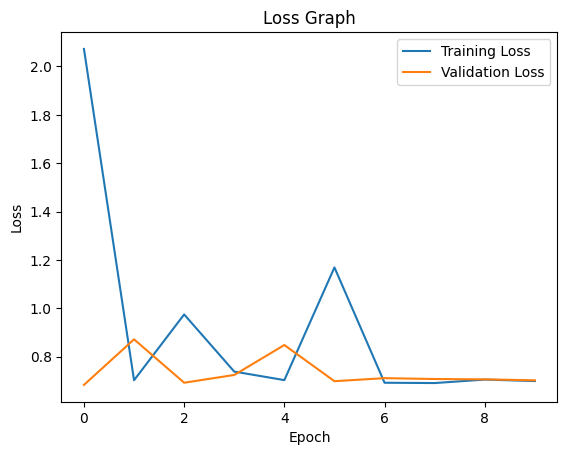

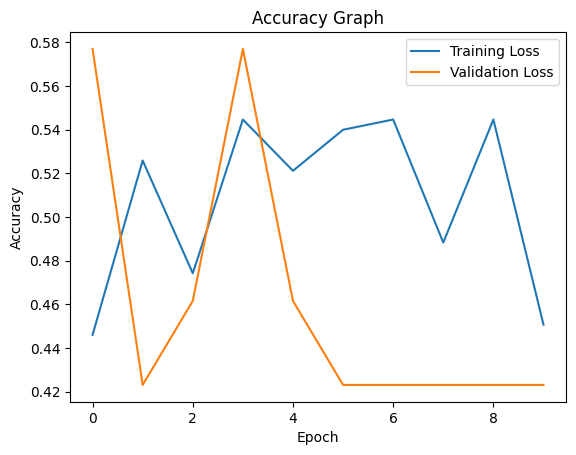


 3.   0.1      64     6      Tanh         BCELoss    SGD          0.7500     GAT

False Positive Rate: 0.2143
False Negative Rate: 0.0357



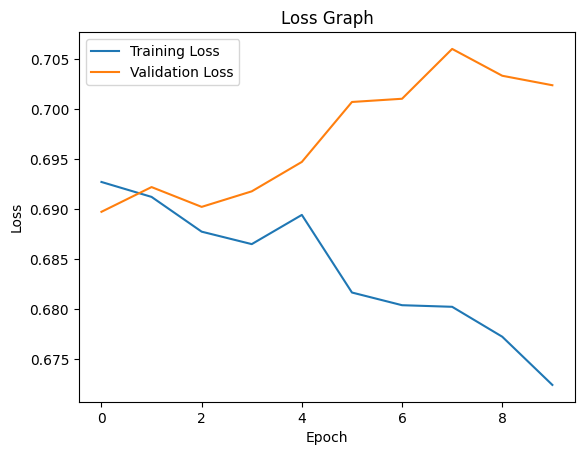

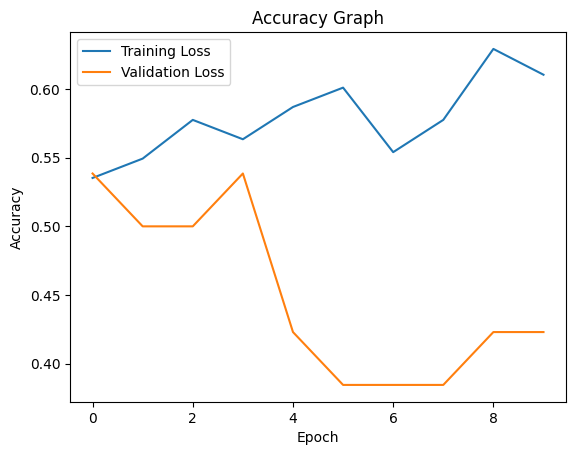


 4.   0.01     64     4      Tanh         MSELoss    SGD          0.7500     GAT

False Positive Rate: 0.0357
False Negative Rate: 0.2143



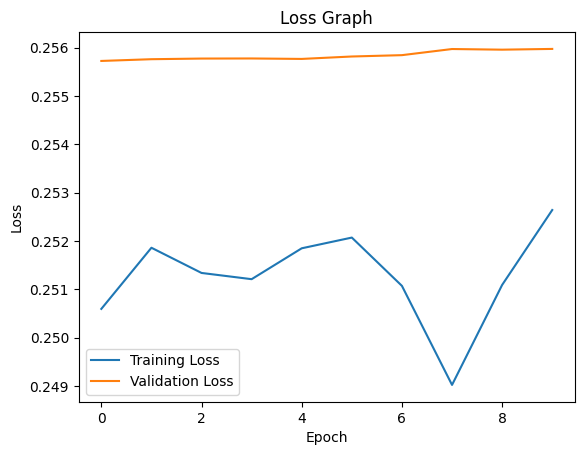

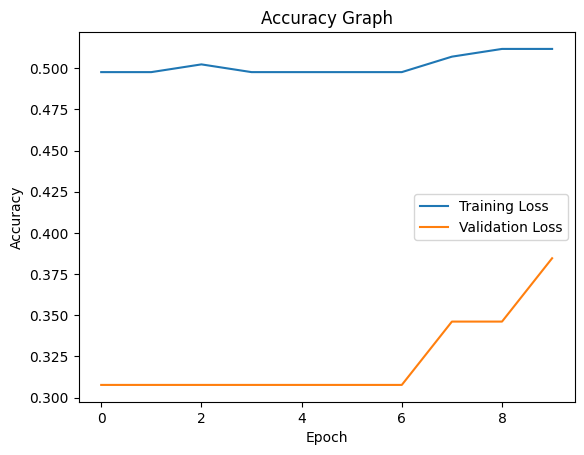


 5.   0.1      4      2      Tanh         BCELoss    Adam         0.7500     ChebConv

False Positive Rate: 0.1429
False Negative Rate: 0.1071



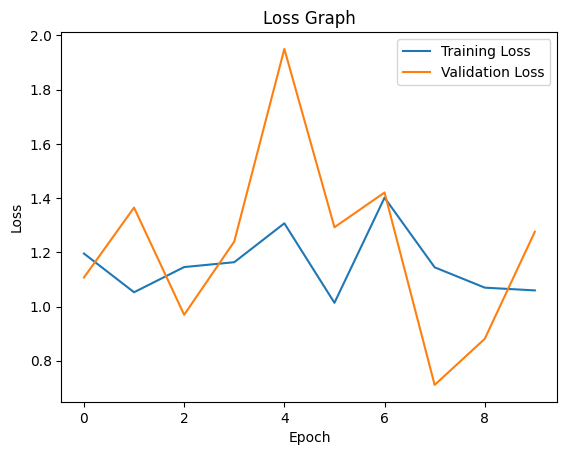

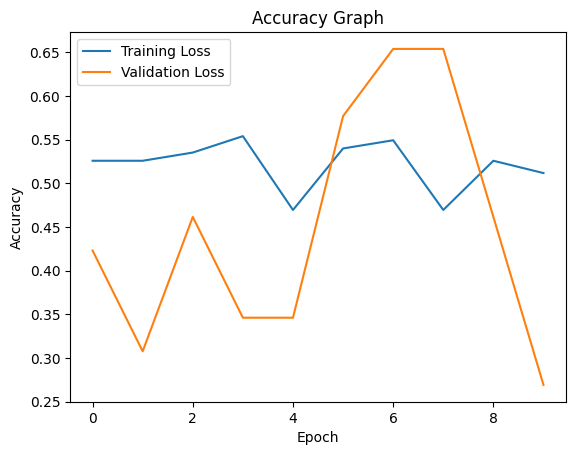

In [ ]:
import time
# Generate random graph data
def relabel_nodes(graph):
    # Create a copy of the graph
    relabeled_graph = copy.deepcopy(graph)

    # Generate a random permutation of node labels
    num_nodes = graph.x.size(0)
    permuted_indices = torch.randperm(num_nodes)

    # Apply the permutation to relabel the nodes and node features
    relabeled_graph.edge_index = permuted_indices[relabeled_graph.edge_index]
    relabeled_graph.x = graph.x[permuted_indices]

    return relabeled_graph

def generate_random_graph(num_nodes):
    while True:
        G = nx.erdos_renyi_graph(num_nodes, 0.2)
        if nx.is_connected(G):  # Check if the generated graph is connected
            break

    edge_index = torch.tensor(list(G.edges)).t().contiguous()
    x = torch.randn(num_nodes, 16)
    return Data(x=x, edge_index=edge_index)

def are_subgraphs_isomorphic(graph1, graph2):
    # Convert edge indices to networkx graphs
    g1 = nx.Graph(graph1.edge_index.t().tolist())
    g2 = nx.Graph(graph2.edge_index.t().tolist())

    # Use nx.is_isomorphic for additional efficiency
    return nx.is_isomorphic(g1, g2)

def generate_dataset(num_samples):
    dataset = []
    num_isomorphic_pairs = num_samples // 3
    num_non_isomorphic_pairs = 2 * (num_samples // 3)

    # Generate isomorphic pairs
    for _ in range(num_isomorphic_pairs):
        num_nodes = torch.randint(3, 8, (1,)).item()

        # Generate a random graph
        base_graph = generate_random_graph(num_nodes)

        # Create an isomorphic copy with randomly relabeled nodes
        relabeled_graph = relabel_nodes(base_graph)

        # Label 1 indicates isomorphic pairs
        label = 1.0
        label_tensor = torch.tensor(label, dtype=torch.float32)

        dataset.append((base_graph, relabeled_graph, label))

    # Generate non-isomorphic pairs
    for _ in range(num_non_isomorphic_pairs, num_samples):
        num_nodes = torch.randint(3, 8, (1,)).item()
        are_subgraphs_iso = True

        while are_subgraphs_iso:
            graph1 = generate_random_graph(num_nodes)
            graph2 = generate_random_graph(num_nodes)
            label = 0.0
            label_tensor = torch.tensor(label, dtype=torch.float32)
            are_subgraphs_iso = are_subgraphs_isomorphic(graph1, graph2)

        dataset.append((graph1, graph2, label))

    random.shuffle(dataset)
    return dataset



class CustomDataset(Dataset):
    def __init__(self, data_pairs):
        self.data_pairs = data_pairs

    def __len__(self):
        return len(self.data_pairs)

    def __getitem__(self, idx):
        data1, data2, label = self.data_pairs[idx]

        return data1, data2, label

def custom_collate(batch):
    # Extract tensors from Data objects and stack them into batches
    data1_batch = [sample[0] for sample in batch]
    data2_batch = [sample[1] for sample in batch]
    label_batch = [sample[2] for sample in batch]

    # Return the collated batch
    return data1_batch, data2_batch, label_batch

def inspect_sample(sample):
    data1, data2, label = sample

    print("Graph 1 Data:")
    print(data1)
    print("\nGraph 2 Data:")
    print(data2)
    print("\nLabel:", label)

#inspect_sample(dataset[0])
#inspect_sample(dataset[1])"""

activation_functions = {
    'ReLU': F.relu,
    'LeakyReLU': F.leaky_relu,
    'Tanh': torch.tanh,
    'Sigmoid': torch.sigmoid
}

loss_functions = ['BCELoss', 'MSELoss']
optimizers = ['Adam', 'SGD']

# Generate a dataset
dataset = generate_dataset(400)

"""def visualize_graph(graph, ax=None):
    if ax is None:
        _, ax = plt.subplots()

    G = nx.Graph(graph.edge_index.t().tolist())
    pos = nx.spring_layout(G)
    nx.draw(G, pos, ax=ax, with_labels=True, font_weight='bold')
    ax.set_title('Graph Visualization')

def visualize_shuffled_dataset(shuffled_dataset, num_samples):
    for i in range(num_samples):
        graph1, graph2, label = shuffled_dataset[i]

        visualize_graph(graph1)

        visualize_graph(graph2)
        print(label)

        plt.show()

# Visualize some random samples from the shuffled dataset
visualize_shuffled_dataset(dataset, num_samples=2)"""

def make_loaders(dataset, batch_size, custom_collate=custom_collate):
    custom_dataset = CustomDataset(dataset)

    # Define the sizes of each split (train, validation, test)
    dataset_size = len(custom_dataset)
    train_size = int(0.8 * dataset_size)  # 80% for training
    val_size = int(0.1 * dataset_size)    # 10% for validation
    test_size = dataset_size - train_size - val_size  # Remaining for testing

    # Use random_split to split the dataset
    train_dataset, val_dataset, test_dataset = random_split(custom_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=custom_collate)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=custom_collate)

    return train_loader, val_loader, test_loader

class SiameseGNNWithDepth(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, depth, activation, gnn_type):
        super(SiameseGNNWithDepth, self).__init__()

        if gnn_type == 'GCN':
            self.conv1 = pyg_nn.GCNConv(input_dim, hidden_dim).to(device)
            self.conv2 = pyg_nn.GCNConv(hidden_dim, output_dim).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.GCNConv(output_dim, output_dim).to(device) for _ in range(depth)])
        elif gnn_type == 'SAGE':
            self.conv1 = pyg_nn.SAGEConv(input_dim, hidden_dim).to(device)
            self.conv2 = pyg_nn.SAGEConv(hidden_dim, output_dim).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.SAGEConv(output_dim, output_dim).to(device) for _ in range(depth)])
        elif gnn_type == 'GAT':
            self.conv1 = pyg_nn.GATConv(input_dim, hidden_dim).to(device)
            self.conv2 = pyg_nn.GATConv(hidden_dim, output_dim).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.GATConv(output_dim, output_dim).to(device) for _ in range(depth)])
        elif gnn_type == 'GraphConv':
            self.conv1 = pyg_nn.GraphConv(input_dim, hidden_dim).to(device)
            self.conv2 = pyg_nn.GraphConv(hidden_dim, output_dim).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.GraphConv(output_dim, output_dim).to(device) for _ in range(depth)])
        elif gnn_type == 'ChebConv':
            self.conv1 = pyg_nn.ChebConv(input_dim, hidden_dim, K=2).to(device)
            self.conv2 = pyg_nn.ChebConv(hidden_dim, output_dim, K=2).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.ChebConv(output_dim, output_dim, K=2).to(device) for _ in range(depth)])
        elif gnn_type == 'ARMAConv':
            self.conv1 = pyg_nn.ARMAConv(input_dim, hidden_dim, num_stacks=2, num_layers=1).to(device)
            self.conv2 = pyg_nn.ARMAConv(hidden_dim, output_dim, num_stacks=2, num_layers=1).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.ARMAConv(output_dim, output_dim,  num_stacks=2, num_layers=1).to(device) for _ in range(depth)])
        elif gnn_type == 'SGConv':
            self.conv1 = pyg_nn.SGConv(input_dim, hidden_dim, K=2).to(device)
            self.conv2 = pyg_nn.SGConv(hidden_dim, output_dim, K=2).to(device)
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.SGConv(output_dim, output_dim, K=2).to(device) for _ in range(depth)])
        elif gnn_type == 'GINConv':
            self.conv1 = pyg_nn.GINConv(nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ))
            self.conv2 = pyg_nn.GINConv(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, output_dim)
            ))
            self.fc = nn.Linear(output_dim * 2, 1).to(device)
            self.additional_layers = nn.ModuleList([pyg_nn.GINConv(nn.Sequential(
                nn.Linear(output_dim, output_dim),
                nn.ReLU(),
                nn.Linear(output_dim, output_dim)
            )).to(device) for _ in range(depth)])

        self.activation = activation_functions[activation]

    def forward(self, data1, data2):
        out1 = []
        out2 = []
        for d1, d2 in zip(data1, data2):
            x1, edge_index1 = d1.x.to(device), d1.edge_index.to(device)
            x2, edge_index2 = d2.x.to(device), d2.edge_index.to(device)

            # Apply graph convolutions with activation function
            x1 = self.activation(self.conv1(x1, edge_index1))
            x1 = self.activation(self.conv2(x1, edge_index1))

            x2 = self.activation(self.conv1(x2, edge_index2))
            x2 = self.activation(self.conv2(x2, edge_index2))

            # Apply additional layers
            for layer in self.additional_layers:
                x1 = self.activation(layer(x1, edge_index1))
                x2 = self.activation(layer(x2, edge_index2))

            # Pooling operation (e.g., mean or max pooling)
            x1_pool = torch.mean(x1, dim=0)
            x2_pool = torch.mean(x2, dim=0)

            out1.append(x1_pool)
            out2.append(x2_pool)

        out1 = torch.stack(out1)
        out2 = torch.stack(out2)

        # Concatenate node embeddings and feed through a fully connected layer
        x = torch.cat([out1, out2], dim=-1)
        x = self.fc(x)
        return torch.sigmoid(x)



def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    for batch_idx, (data1, data2, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data1, data2)

        labels = torch.tensor(labels).to(device)
        labels = torch.unsqueeze(labels, 1)

        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Calculate training accuracy
        predicted = torch.round(output)
        label_int = labels.squeeze().long()
        predicted_int = torch.round(predicted).squeeze().long()
        correct_train += torch.sum(abs(label_int - predicted_int) < 0.5).item()
        total_train += label_int.numel()

    average_loss = total_loss / len(train_loader)
    accuracy = correct_train / total_train

    return average_loss, accuracy

def validate(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_idx, (data1, data2, labels) in enumerate(val_loader):
            output = model(data1, data2)

            labels = torch.tensor(labels).to(device)
            labels = torch.unsqueeze(labels, 1)

            val_loss += criterion(output, labels).item()

            # Calculate validation accuracy
            predicted = torch.round(output)
            label_int = labels.squeeze().long()
            predicted_int = torch.round(predicted).squeeze().long()
            correct_val += torch.sum(abs(label_int - predicted_int) < 0.5).item()
            total_val += label_int.numel()

    val_loss /= len(val_loader)
    accuracy = correct_val / total_val

    return val_loss, accuracy

def test(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0
    false_positives = 0
    false_negatives = 0

    with torch.no_grad():
        for batch_idx, (data1, data2, labels) in enumerate(test_loader):
            output = model(data1, data2)

            labels = torch.tensor(labels).to(device)
            labels = torch.unsqueeze(labels, 1)

            test_loss += criterion(output, labels).item()

            # Calculate test accuracy
            predicted = torch.round(output)
            label_int = labels.squeeze().long()
            predicted_int = torch.round(predicted).squeeze().long()
            correct_test += torch.sum(predicted_int == label_int).item()
            total_test += label_int.numel()

            # Calculate false positives and false negatives
            false_positives += torch.sum((predicted_int == 1) & (label_int == 0)).item()
            false_negatives += torch.sum((predicted_int == 0) & (label_int == 1)).item()

    test_loss /= len(test_loader)
    accuracy = correct_test / total_test
    false_positive_rate = false_positives / total_test
    false_negative_rate = false_negatives / total_test

    return test_loss, accuracy, false_positive_rate, false_negative_rate

import matplotlib.pyplot as plt




input_dim = 16
hidden_dim = 32
output_dim = 64

def train_model(gnn_type, activation, depth, batch_size, learning_rate, num_epochs, dataset, loss_function, optimizer_type):
    train_loader, val_loader, test_loader = make_loaders(dataset, batch_size)
    model = SiameseGNNWithDepth(input_dim, hidden_dim, output_dim, depth, activation, gnn_type).to(device)

    if loss_function == 'BCELoss':
        criterion = nn.BCELoss()
    elif loss_function == 'MSELoss':
        criterion = nn.MSELoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_epoch = -1

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, criterion)
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        #val_loss, train_loss = 0.8, 0.6
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        #print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), f'{gnn_type}_{activation}_{depth}_{batch_size}_{learning_rate}_{num_epochs}_{loss_function}_{optimizer_type}.pth')

    # Load best model
    model.load_state_dict(torch.load(f'{gnn_type}_{activation}_{depth}_{batch_size}_{learning_rate}_{num_epochs}_{loss_function}_{optimizer_type}.pth'))
    test_loss, test_accuracy, false_positive_rate, false_negative_rate = test(model, test_loader, criterion)

    #result_text = f'Best Epoch: {best_epoch+1}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, False Positive Rate: {false_positive_rate:.4f}, False Negative Rate: {false_negative_rate:.4f}'

    """#Plotting the graphs with smaller size
    plt.figure(figsize=(6, 2))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='TrL')
    plt.plot(val_losses, label='ValL')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='TrA')
    plt.plot(val_accuracies, label='ValA')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    #print(result_text)"""

    return test_loss, test_accuracy, false_positive_rate, false_negative_rate, model, train_losses, val_losses, train_accuracies, val_accuracies

"""try:
    with open('drive/MyDrive/Colab Notebooks/experiment_results.pkl', 'rb') as f:
        resultsPickle = pickle.load(f)
except FileNotFoundError:
    print("file does not exist")
except RuntimeError as e:
    if not 'torch.cuda.is_available()' in str(e):
        # CUDA error, load the model onto CPU
        resultsPickle = torch.load('drive/MyDrive/Colab Notebooks/experiment_results.pkl', map_location=torch.device('cpu'))
    else:
        raise  # Reraise other errors"""

if os.path.exists('drive/MyDrive/Colab Notebooks/experiment_results.json'):
    # Read existing data from JSON file
    with open('drive/MyDrive/Colab Notebooks/experiment_results.json', 'r') as jsonfile:
        resultsJson = json.load(jsonfile)

# Define hyperparameters
gnn_types = ['GCN',  'SGConv', 'Chebconv', 'GINConv', 'ARMAConv', 'GraphConv', 'GAT', 'SAGE']
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]
batch_sizes = [4, 16, 64]
depths = [2, 4, 6]
loss_functions = ['MSELoss','BCELoss']
optimizers = ['Adam', 'SGD']
activation_functions = {
    'ReLU': F.relu,
    'LeakyReLU': F.leaky_relu,
    'Tanh': torch.tanh,
    'Sigmoid': torch.sigmoid
}

def plot_graph(train_losses, val_losses, graph):
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    if graph == "Loss":
        plt.title('Loss Graph')
        plt.ylabel('Loss')
    elif graph == "Accuracy":
        plt.title('Accuracy Graph')
        plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


def retrain_with_top_parameters(result):
    # Double the dataset size
    dataset = generate_dataset(400)

    # Initialize lists to store loss values
    train_losses = []
    valid_losses = []

    gnn_type = result['gnn_type']
    learning_rate = result['learning_rate']
    batch_size = result['batch_size']
    depth = result['depth']
    activation_function = result['activation_function']
    loss_function = result['loss_function']
    optimizer = result['optimizer']

    # Train the model
    test_loss, test_accuracy, false_positive_rate, false_negative_rate, model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(gnn_type, activation_function, depth, batch_size, learning_rate, num_epochs=8, dataset=dataset, loss_function=loss_function, optimizer_type=optimizer)

    # Plot the loss graph
    plot_graph(train_losses, val_losses, "Loss")
    plot_graph(train_accuracies, val_accuracies, "Accuracy")
    print(f" {i}.   {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {test_accuracy:<5.4f}     {result['gnn_type']}")
    print(f"False Positive Rate: {false_positive_rate:.4f}")
    print(f"False Negative Rate: {false_negative_rate:.4f}")





# Generate combinations of hyperparameters
hyperparameter_combinations = itertools.product(gnn_types, learning_rates, batch_sizes, depths, activation_functions, loss_functions, optimizers)

#print("Learning Rate  Batch Size  Depth  Activation  Loss Function  Optimizer  GNN Type  Accuracy  FN Rate  FP Rate")

results = resultsJson
#results = resultsPickle


# Loop over combinations and print results
for combo in hyperparameter_combinations:
    start_time = time.time()
    gnn_type, learning_rate, batch_size, depth, activation_function, loss_function, optimizer = combo
    #print(f"{learning_rate:<13} {batch_size:<11} {depth:<6} {activation_function:<11} {loss_function:<14} {optimizer:<10} {gnn_type:<9} ")
    test_loss, test_accuracy, false_positive_rate, false_negative_rate, model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(gnn_type, activation_function, depth, batch_size, learning_rate, num_epochs=10, dataset=dataset, loss_function=loss_function, optimizer_type=optimizer)
    end_time = time.time()  # Record end time
    training_time = end_time - start_time  # Calculate training time

    results.append({
        'gnn_type': gnn_type,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'depth': depth,
        'activation_function': activation_function,
        'loss_function': loss_function,
        'optimizer': optimizer,
        'test_accuracy': test_accuracy,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate,
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies':train_accuracies,
        'val_accuracies':val_accuracies
    })

# Sort results by test accuracy
sorted_results = sorted(results, key=lambda x: x['test_accuracy'], reverse=True)

# Print header
"""print("Learning Rate  Batch Size  Depth  Activation  Loss Function  Optimizer  GNN Type  Test Accuracy  FN Rate  FP Rate")

# Print sorted results
for result in sorted_results:
    print(f"{result['learning_rate']:<13} {result['batch_size']:<12} {result['depth']:<6} {result['activation_function']:<11} {result['loss_function']:<14} {result['optimizer']:<10} {result['gnn_type']:<9} {result['test_accuracy']:<13.4f} {result['false_positive_rate']:<10.4f} {result['false_negative_rate']:<10.4f}")
"""

#Save updated results to file
"""with open('drive/MyDrive/Colab Notebooks/experiment_results.pkl', 'wb') as f:
   pickle.dump(results, f)"""

with open('drive/MyDrive/Colab Notebooks/experiment_results.json', 'w') as jsonfile:
    json.dump(sorted_results, jsonfile)

# Define function to filter top results for each GNN type
def get_top_results_by_gnn_type(results, gnn_type, top_n=20):
    filtered_results = [result for result in results if result['gnn_type'] == gnn_type]
    sorted_results = sorted(filtered_results, key=lambda x: x['test_accuracy'], reverse=True)
    return sorted_results[:top_n]

# Print top 10 results for each GNN type
gnn_types = ['GCN', 'GraphConv', 'SAGE', 'GAT', 'ChebConv', 'ARMAConv', 'SGConv', 'GINConv']
for gnn_type in gnn_types:
    top_results = get_top_results_by_gnn_type(sorted_results, gnn_type)
    print(f"Top 10 results for {gnn_type}:")
    print(f"")
    print("      lr       b      d      activation   loss       optimizer   accuracy")
    for i, result in enumerate(top_results, 1):
        if i >= 10:
          print(f" {i}.  {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<5.4f}")
          #{result['training_time']:<5.4f}")
        else:
          print(f" {i}.   {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<5.4f}")
          # {result['training_time']:<5.4f}")
          #print(f"  {i}. LR: {result['learning_rate']}, Batch Size: {result['batch_size']}, Depth: {result['depth']}, Activation: {result['activation_function']}, Loss: {result['loss_function']}, Optimizer: {result['optimizer']}, Test Accuracy: {result['test_accuracy']:.4f}")
    print()

top_results = []
# Print top 10 results from all GNNs
print("Top 5 results from all GNNs:")
print("")
print("      lr       b      d      activation   loss       optimizer    accuracy        FP         FN     GNN Type")
for i, result in enumerate(sorted_results[:10], 1):
      if i >= 10:
          print(f" {i}.  {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<11.4f} {result['false_positive_rate']:<10.4f} {result['false_negative_rate']:<10.4f} {result['gnn_type']}")
      else:
          print(f" {i}.   {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<11.4f} {result['false_positive_rate']:<10.4f} {result['false_negative_rate']:<10.4f} {result['gnn_type']}")



for i, result in enumerate(sorted_results[:5], 1):
      if i >= 10:
          print(f" {i}.  {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<5.4f}     {result['gnn_type']}")
          print("")
          print(f"    False Positive Rate: {result['false_positive_rate']:.4f}")
          print(f"    False Negative Rate: {result['false_negative_rate']:.4f}")
          print("")
          plot_graph(result['train_losses'], result['val_losses'], "Loss")
          plot_graph(result['train_accuracies'], result['val_accuracies'], "Accuracy")
          print("")
      else:
          print(f" {i}.   {result['learning_rate']:<8} {result['batch_size']:<6} {result['depth']:<6} {result['activation_function']:<12} {result['loss_function']:<10} {result['optimizer']:<12} {result['test_accuracy']:<5.4f}     {result['gnn_type']}")
          print("")
          print(f"False Positive Rate: {result['false_positive_rate']:.4f}")
          print(f"False Negative Rate: {result['false_negative_rate']:.4f}")
          print("")
          plot_graph(result['train_losses'], result['val_losses'], "Loss")
          plot_graph(result['train_accuracies'], result['val_accuracies'], "Accuracy")
          print("")